In [1]:
import doodads as dd
from doodads.ref.solar_system import JUPITER_SURFBRIGHT

To use the composite measured spectra of Jupiter and others from [CDBS](https://www.stsci.edu/hst/instrumentation/reference-data-for-calibration-and-tools/astronomical-catalogs/solar-system-objects-spectra), we have to contend with surface brightness units.

<Axes: xlabel='Wavelength [um]', ylabel='[erg / (Angstrom s arcsec2 cm2)]'>

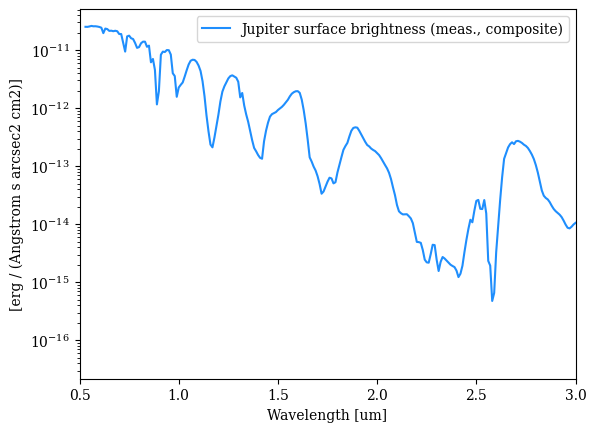

In [2]:
dd.JUPITER_SURFBRIGHT.display(begin=0.5*u.um, end=3*u.um)

The spectra $I_\lambda$ are in units of energy / time / area / wavelength / solid angle. The solid angle of a point source is theoretically infinitely small, so how do we integrate out the solid angle and get to spectral flux density at an observer?

\begin{align*}
F_\lambda &= \int_\mathrm{disk} I_\lambda \mathrm{d}\Omega\\
&= \langle I_\lambda \rangle \Omega_\mathrm{disk}
\end{align*}

But then, we need $\Omega_\mathrm{disk}$. That took on different values in different observations in the composite spectrum, so it's not a simple matter of multiplying it back out.

A sphere of radius $R$ observed from a distance $D$ subtends a solid angle that is a disk of radius $\theta$, and solid angle $\Omega = \pi\theta^2$. 

From the notional observer's distance, $\sin \theta = R / D$. As $D \gg R$, $\theta\ \mathrm{[rad]} \approx R / D$. So, $$\Omega \ \mathrm{[sr]}\approx \pi \left(\frac{R}{D}\right)^2.$$

Note that this is in steradians, not arcsec<sup>2</sup>. Unfortunately, we still don't know $D$, but this will help us later.

$F_\lambda$ is the spectral flux density (energy per time per unit area per wavelength) observed at some distance $D$. If we assume an isotropic radiator (**only** a good idea for black-body thermal emission, or a rough calculation like this one) we can get from the flux to the spectral luminosity (energy per time per wavelength). Because the flux per area at distance $D$ is just the total luminosity divided by the area of the sphere centered on the radiator with radius $D$:
<!-- \langle I_\lambda \rangle \Omega_\mathrm{disk}  -->

\begin{align*}
    F_\lambda &= \frac{L_\lambda}{4 \pi D}\\
    \langle I_\lambda \rangle \pi \left(\frac{R}{D}\right)^2 &= \frac{L_\lambda}{4 \pi D^2}
\end{align*}

The unfortunate $D^{-2}$ cancels:

\begin{align*}
    \langle I_\lambda \rangle \pi R^2 &= \frac{L_\lambda}{4 \pi}\\
    L_\lambda &= 4 \pi^2 R^2 \langle I_\lambda \rangle
\end{align*}

Spectral luminosity is intrinsic and a fine thing to have as a distance-indepedent quantity. But then, of course, we want to model observations, so there's a new distance $d$ from us to the target and $F_\lambda^\mathrm{obs}$ spectral flux density at the observer:

\begin{align*}
    F_\lambda^\mathrm{obs} &= \frac{L_\lambda}{4 \pi d^2} = 4 \pi^2 R^2 \langle I_\lambda \rangle\\
    F_\lambda^\mathrm{obs} &= \pi \langle I_\lambda \rangle \left(\frac{R}{d}\right)^2\\
\end{align*}

Let's assume (unphysically) that we are looking at Jupiter in opposition, all the way across the solar system. The distance then becomes (approximately) Jupiter's semi-major axis plus 1 au for Earth's.

In [3]:
dist = 6.2 * u.au

In that case we would be seeing the entire illuminated disk, so there would be no additional scale factor for the "phase" of the planet.

<Axes: xlabel='Wavelength [um]', ylabel='[W / m3]'>

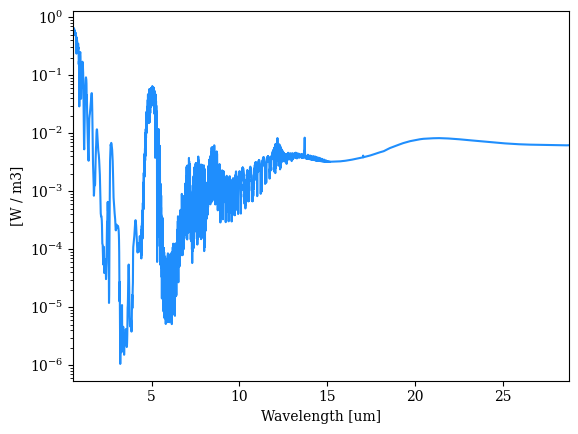

In [4]:
JUPITER_FROM_EARTH = dd.JUPITER_SURFBRIGHT.multiply(((np.pi * (1 * u.Rjup) / dist) * u.radian)**2)
JUPITER_FROM_EARTH.display(wavelength_unit=u.um, value_unit=u.W / u.m**3, legend=False)

Since we don't have the Johnson filters in this package (yet?), we approximate with a top-hat:

In [5]:
johnson_V = dd.TopHat(0.549 * u.um, 0.086 * u.um)

In [6]:
dd.VEGA.magnitude(JUPITER_FROM_EARTH, johnson_V)

<Quantity -2.83931988>

This rough approximation is consistent with [Table 4 of Mallama & Hilton](https://www.sciencedirect.com/science/article/pii/S221313371830009X?via%3Dihub#tbl4), which reports an upper limit of $V = -2.94$ for Jupiter's apparent magnitude.